# 기말고사 Template 1 - Data Pipeline

**이름:** __이나연__ &nbsp; **학번:** __20251258__

## 사용 데이터
- 입력 파일: `C:/Users/DS/Desktop/acute_oral.xlsx`
- 데이터 출처: NTP ICE acute oral toxicity 데이터
- 분석 대상: `Mixture == Chemical`, `Endpoint == LD50`, 유효한 `SMILES`가 있는 화합물
- 최종 출력: `C:/Users/DS/Desktop/final_dataset_descriptors.csv`

## Label 정의
LD50은 급성 경구 독성을 나타내는 대표 지표이며, 값이 낮을수록 독성이 강하다는 의미이다.

- `label = 1`: acute toxic, `LD50 <= 2000 mg/kg`
- `label = 0`: lower toxicity, `LD50 > 2000 mg/kg`

`Response_Modifier`가 `>` 또는 `<`인 경우, 2000 mg/kg 기준으로 라벨을 명확히 판단할 수 있는 행만 사용하고 애매한 행은 제거하였다.

In [1]:
# 1. 라이브러리 불러오기

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import Descriptors, AllChem

RDLogger.DisableLog('rdApp.*')

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

In [2]:
# 2. 데이터 불러오기 및 기본 구조 확인

input_path = r'C:/Users/DS/Desktop/acute_oral.xlsx'
output_path = r'C:/Users/DS/Desktop/final_dataset_descriptors.csv'

excel_file = pd.ExcelFile(input_path)
print('시트 목록:', excel_file.sheet_names)

df_raw = pd.read_excel(input_path, sheet_name='Data')
print('원본 데이터 크기:', df_raw.shape)
display(df_raw.head())

print()
print('컬럼 목록')
print(df_raw.columns.tolist())

시트 목록: ['Metadata', 'Data']
원본 데이터 크기: (16721, 23)


,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Response_Modifier,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,acute_oral_12325,In Vivo,MIX86,Captevate 68 WDG,Captan-related-substance,NaN,NaN,1.200,Mixture,Rat,...,NaN,5.0,Unitless,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
1,acute_oral_12322,In Vivo,MIX82,Captan 4L,Captan-related-substance,NaN,NaN,0.970,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
2,acute_oral_12133,In Vivo,MIX617,5-Hydroxy-Tepraloxydim,Tepraloxydim-5-hydroxy,15479-55-0,NaN,89.600,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
3,acute_oral_12132,In Vivo,MIX617,5-Hydroxy-Tepraloxydim,Tepraloxydim-5-hydroxy,15479-55-0,NaN,89.600,Mixture,Rat,...,>,5000.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN
4,acute_oral_12894,In Vivo,MIX380,Raid Roach & Ant Killer Plus,Dichlorvos-related-substance,NaN,NaN,0.014,Mixture,Rat,...,NaN,3710.0,mg/kg,Studies submitted to EPA in support of pestici...,NaN,NaN,NaN,NaN,NaN,NaN



컬럼 목록
['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Mixture', 'Species', 'Sex', 'Assay', 'Endpoint', 'Response_Modifier', 'Response', 'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox', 'URL_CEBS']


In [3]:
# 3. 전처리 전 데이터 분포 확인

summary_cols = ['Data_Type', 'Mixture', 'Species', 'Sex', 'Assay', 'Endpoint', 'Response_Unit', 'Response_Modifier']
for col in summary_cols:
    print()
    print(f'[{col}]')
    display(df_raw[col].value_counts(dropna=False).head(20))

print()
print('SMILES 결측 개수:', df_raw['SMILES'].isna().sum())
print('SMILES 보유 개수:', df_raw['SMILES'].notna().sum())


[Data_Type]


Data_Type
In Vivo    16721
Name: count, dtype: int64


[Mixture]


Mixture
Chemical    12207
Mixture      4514
Name: count, dtype: int64


[Species]


...


[Response_Unit]


Response_Unit
mg/kg       13512
Unitless     3209
Name: count, dtype: int64


[Response_Modifier]


Response_Modifier
NaN    12440
>       3857
<        424
Name: count, dtype: int64


SMILES 결측 개수: 484
SMILES 보유 개수: 16237


In [4]:
# 4. 과제용 데이터 필터링
# 단일 화학물질이며 LD50 값과 SMILES가 있는 행만 선택한다.

df = df_raw.copy()

cond_chemical = df['Mixture'].astype(str).str.strip().str.lower().eq('chemical')
cond_ld50 = df['Endpoint'].astype(str).str.strip().str.upper().eq('LD50')
cond_smiles = df['SMILES'].notna()
cond_response = df['Response'].notna()

df_ld50 = df[cond_chemical & cond_ld50 & cond_smiles & cond_response].copy()
df_ld50['Response'] = pd.to_numeric(df_ld50['Response'], errors='coerce')
df_ld50 = df_ld50.dropna(subset=['Response'])

print('필터링 후 데이터 크기:', df_ld50.shape)
display(df_ld50[['Chemical_Name', 'Species', 'Endpoint', 'Response_Modifier', 'Response', 'Response_Unit', 'SMILES']].head())

필터링 후 데이터 크기: (11948, 23)


,Chemical_Name,Species,Endpoint,Response_Modifier,Response,Response_Unit,SMILES
46,(2-Chloropyridin-3-yl)(phenyl)methanol,Rat,LD50,>,2000.0,mg/kg,OC(C1=CC=CC=C1)C1=C(Cl)N=CC=C1
47,"2-(4-Methoxyphenyl)-5,6-dihydro-2H-1,3-thiazin...",Rat,LD50,>,8000.0,mg/kg,COC1=CC=C(C=C1)C1SCCC(O)=N1
48,"Bis(2-ethylhexyl) cyclohexane-1,4-dicarboxylate",Rat,LD50,>,2000.0,mg/kg,CCCCC(CC)COC(=O)C1CCC(CC1)C(=O)OCC(CC)CCCC
49,2-Methyl-6-methylideneoctyl acetate,Rat,LD50,>,5000.0,mg/kg,CCC(=C)CCCC(C)COC(C)=O
50,"O,S-Dimethyl propylphosphonothioate",Rat,LD50,NaN,25.0,mg/kg,CCCP(=O)(OC)SC


In [5]:
# 5. LD50 기준 이진 label 생성
# Response_Modifier가 있어도 threshold 기준으로 명확히 판정 가능한 행만 사용한다.

threshold = 2000

def make_ld50_label(row):
    value = row['Response']
    modifier = row['Response_Modifier']

    if pd.isna(modifier):
        return 1 if value <= threshold else 0

    modifier = str(modifier).strip()
    if modifier == '>':
        if value >= threshold:
            return 0
        return np.nan
    if modifier == '<':
        if value <= threshold:
            return 1
        return np.nan
    return np.nan

df_ld50['label'] = df_ld50.apply(make_ld50_label, axis=1)
ambiguous_n = df_ld50['label'].isna().sum()
df_labeled = df_ld50.dropna(subset=['label']).copy()
df_labeled['label'] = df_labeled['label'].astype(int)

print('라벨 판정이 애매해서 제거한 행 수:', ambiguous_n)
print('라벨 생성 후 데이터 크기:', df_labeled.shape)
print()
print('Label 분포')
display(df_labeled['label'].value_counts().rename(index={0: '0_lower_toxicity', 1: '1_acute_toxic'}))

라벨 판정이 애매해서 제거한 행 수: 910
라벨 생성 후 데이터 크기: (11038, 24)

Label 분포


label
1_acute_toxic       6181
0_lower_toxicity    4857
Name: count, dtype: int64

In [6]:
# 6. SMILES 표준화 및 salt/fragment 정리
# RDKit이 읽을 수 없는 SMILES는 제거하고, 여러 fragment가 있으면 가장 큰 fragment를 대표 구조로 사용한다.

def standardize_smiles(smiles):
    if pd.isna(smiles) or not isinstance(smiles, str):
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fragments = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    if len(fragments) == 0:
        return None

    main_mol = max(fragments, key=lambda m: m.GetNumHeavyAtoms())
    if main_mol.GetNumHeavyAtoms() == 0:
        return None

    return Chem.MolToSmiles(main_mol, canonical=True)

df_labeled['standardized_smi'] = df_labeled['SMILES'].apply(standardize_smiles)
df_valid = df_labeled.dropna(subset=['standardized_smi']).copy()

print('SMILES 표준화 전:', len(df_labeled))
print('SMILES 표준화 후:', len(df_valid))
display(df_valid[['Chemical_Name', 'SMILES', 'standardized_smi', 'label']].head())

SMILES 표준화 전: 11038
SMILES 표준화 후: 11031


,Chemical_Name,SMILES,standardized_smi,label
46,(2-Chloropyridin-3-yl)(phenyl)methanol,OC(C1=CC=CC=C1)C1=C(Cl)N=CC=C1,OC(c1ccccc1)c1cccnc1Cl,0
47,"2-(4-Methoxyphenyl)-5,6-dihydro-2H-1,3-thiazin...",COC1=CC=C(C=C1)C1SCCC(O)=N1,COc1ccc(C2N=C(O)CCS2)cc1,0
48,"Bis(2-ethylhexyl) cyclohexane-1,4-dicarboxylate",CCCCC(CC)COC(=O)C1CCC(CC1)C(=O)OCC(CC)CCCC,CCCCC(CC)COC(=O)C1CCC(C(=O)OCC(CC)CCCC)CC1,0
49,2-Methyl-6-methylideneoctyl acetate,CCC(=C)CCCC(C)COC(C)=O,C=C(CC)CCCC(C)COC(C)=O,0
50,"O,S-Dimethyl propylphosphonothioate",CCCP(=O)(OC)SC,CCCP(=O)(OC)SC,1


In [7]:
# 7. 중복 화합물 및 label 충돌 처리
# 같은 standardized_smi에 서로 다른 label이 있으면 분석 기준이 흔들리므로 제거한다.

print('표준화 SMILES 기준 중복 행 수:', df_valid.duplicated('standardized_smi').sum())

label_nunique = df_valid.groupby('standardized_smi')['label'].transform('nunique')
conflict_df = df_valid[label_nunique > 1].copy()
consistent_df = df_valid[label_nunique == 1].copy()

print('label 충돌 행 수:', len(conflict_df))
print('label 충돌 제거 후 행 수:', len(consistent_df))

df_final = consistent_df.sort_values('Response').drop_duplicates(subset='standardized_smi', keep='first').copy()
df_final = df_final.reset_index(drop=True)

print('최종 unique compound 수:', len(df_final))
print()
print('최종 label 분포')
display(df_final['label'].value_counts().sort_index())

표준화 SMILES 기준 중복 행 수: 2920
label 충돌 행 수: 1061
label 충돌 제거 후 행 수: 9970
최종 unique compound 수: 7835

최종 label 분포


label
0    3492
1    4343
Name: count, dtype: int64

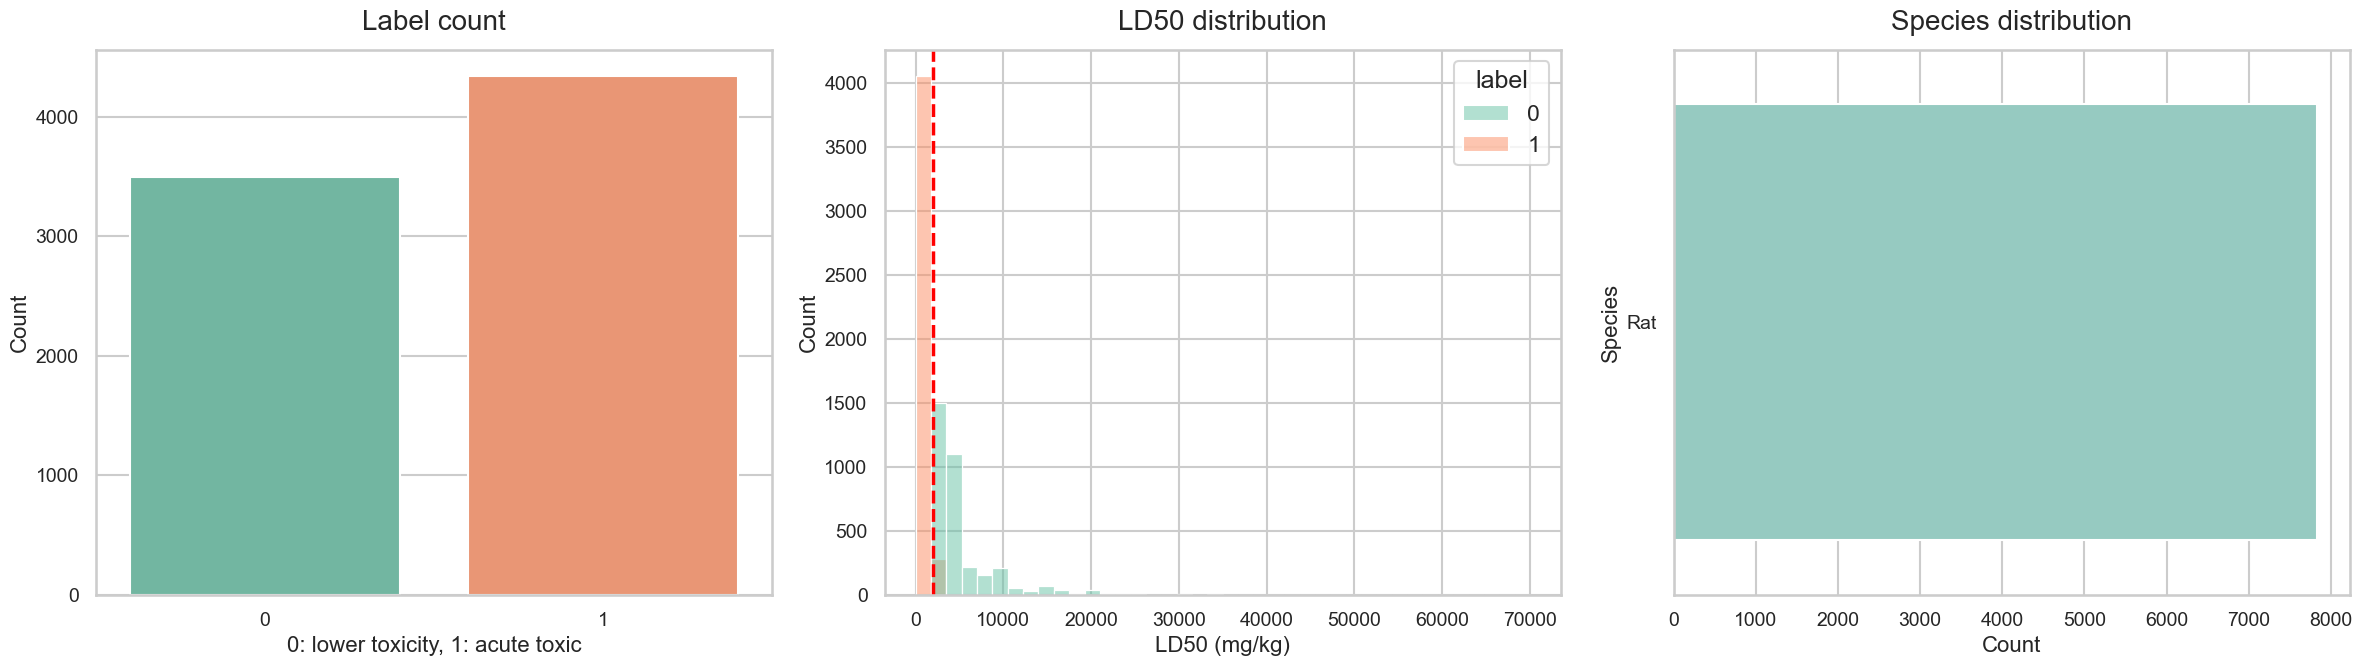

In [8]:
# 8. 데이터 시각화 - label, LD50, species 분포

sns.set_context('talk')
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.countplot(data=df_final, x='label', ax=axes[0], palette='Set2')
axes[0].set_title('Label count', fontsize=20, pad=14)
axes[0].set_xlabel('0: lower toxicity, 1: acute toxic', fontsize=16)
axes[0].set_ylabel('Count', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)

sns.histplot(data=df_final, x='Response', hue='label', bins=40, ax=axes[1], palette='Set2')
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2.5, label='LD50 2000 mg/kg')
axes[1].set_title('LD50 distribution', fontsize=20, pad=14)
axes[1].set_xlabel('LD50 (mg/kg)', fontsize=16)
axes[1].set_ylabel('Count', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

sns.countplot(data=df_final, y='Species', order=df_final['Species'].value_counts().index, ax=axes[2], palette='Set3')
axes[2].set_title('Species distribution', fontsize=20, pad=14)
axes[2].set_xlabel('Count', fontsize=16)
axes[2].set_ylabel('Species', fontsize=16)
axes[2].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

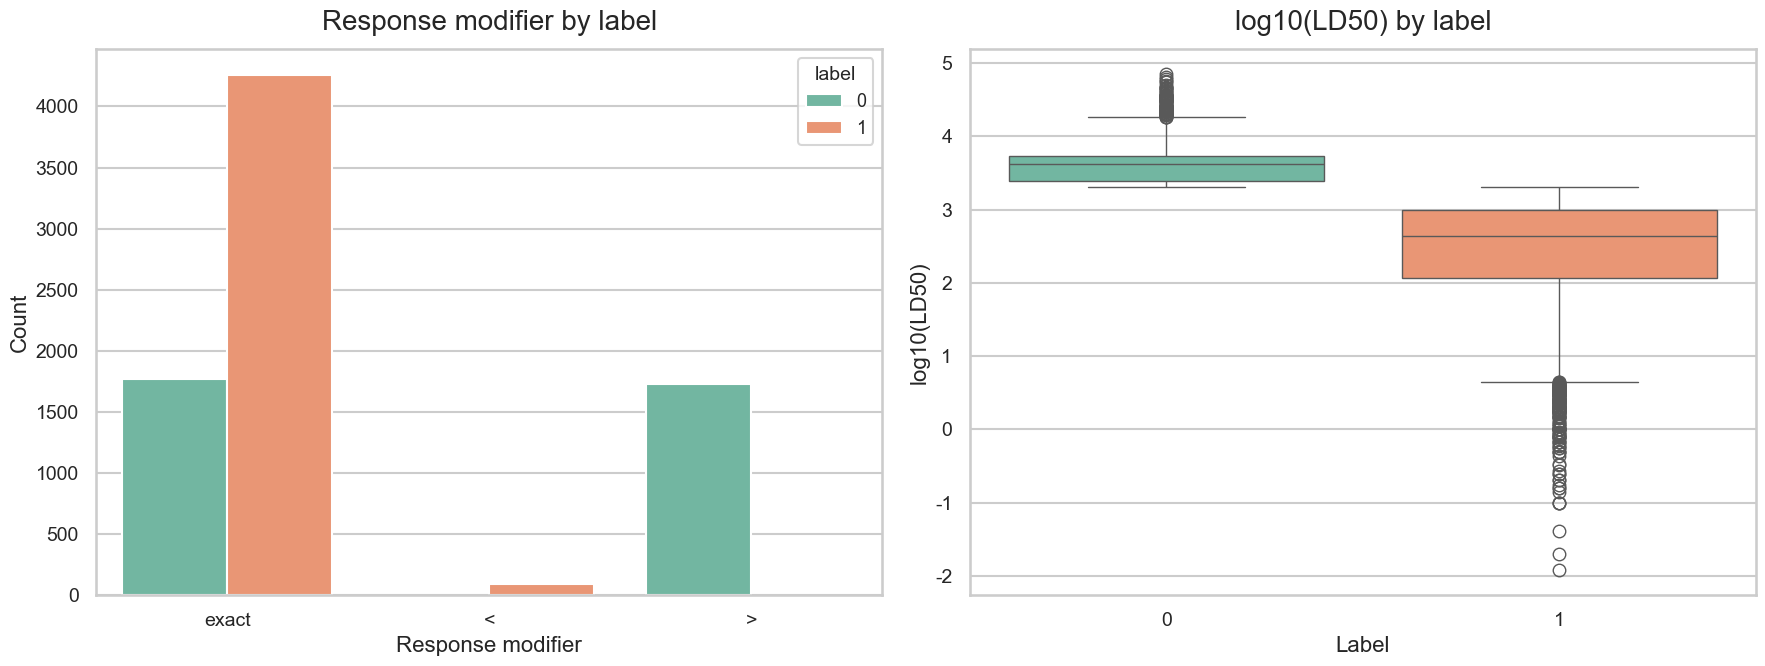

In [9]:
# 9. 데이터 시각화 - response modifier와 log LD50 분포

plot_df = df_final.copy()
plot_df['log10_LD50'] = np.log10(plot_df['Response'])
plot_df['Response_Modifier_filled'] = plot_df['Response_Modifier'].fillna('exact')

sns.set_context('talk')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(data=plot_df, x='Response_Modifier_filled', hue='label', ax=axes[0], palette='Set2')
axes[0].set_title('Response modifier by label', fontsize=20, pad=14)
axes[0].set_xlabel('Response modifier', fontsize=16)
axes[0].set_ylabel('Count', fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].legend(title='label', fontsize=13, title_fontsize=14)

sns.boxplot(data=plot_df, x='label', y='log10_LD50', ax=axes[1], palette='Set2')
axes[1].set_title('log10(LD50) by label', fontsize=20, pad=14)
axes[1].set_xlabel('Label', fontsize=16)
axes[1].set_ylabel('log10(LD50)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

In [10]:
# 10. RDKit 2D descriptor 계산
# Descriptors.CalcMolDescriptors는 RDKit 기본 2D descriptor를 dictionary 형태로 반환한다.

def calc_2d_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        return Descriptors.CalcMolDescriptors(mol)
    except Exception:
        return None

desc_records = []
valid_indices = []

for idx, smi in df_final['standardized_smi'].items():
    desc = calc_2d_descriptors(smi)
    if desc is not None:
        desc_records.append(desc)
        valid_indices.append(idx)

desc_df = pd.DataFrame(desc_records)
df_desc_base = df_final.loc[valid_indices, ['Chemical_Name', 'CASRN', 'SMILES', 'standardized_smi', 'Response', 'Response_Unit', 'label']].reset_index(drop=True)

desc_df = desc_df.replace([np.inf, -np.inf], np.nan)
desc_df = desc_df.dropna(axis=1)

print('Descriptor 계산 성공 화합물 수:', len(df_desc_base))
print('NaN 제거 후 descriptor 개수:', desc_df.shape[1])
display(desc_df.head())

Descriptor 계산 성공 화합물 수: 7835
NaN 제거 후 descriptor 개수: 205


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.676825,5.676825,0.345019,0.345019,0.605684,25.742857,480.649,440.329,480.298808,190,...,0,0,0,0,0,0,0,0,0,0
1,5.914545,5.914545,0.391229,0.391229,0.490572,12.222222,321.974,317.942,319.896540,92,...,0,0,0,0,0,0,0,0,0,0
2,13.011064,13.011064,0.077001,-5.771605,0.335502,35.361111,524.586,486.282,524.272514,206,...,0,0,0,0,0,0,0,0,0,0
3,10.453704,10.453704,1.388889,-1.662037,0.390207,7.400000,77.034,75.018,77.004431,30,...,0,0,0,0,0,0,0,0,0,0
4,11.921396,11.921396,0.093391,-2.969414,0.717823,27.866667,252.276,235.140,252.069750,88,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# 11. Morgan fingerprint 계산
# descriptor 다양성을 위해 RDKit 2D descriptor 외 Morgan fingerprint bit를 추가한다.

def calc_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.full(n_bits, np.nan)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

n_bits = 2048
fp_array = np.vstack(df_desc_base['standardized_smi'].apply(lambda x: calc_morgan_fp(x, radius=2, n_bits=n_bits)))
fp_df = pd.DataFrame(fp_array, columns=[f'morgan_{i}' for i in range(n_bits)])

print('Morgan fingerprint shape:', fp_df.shape)
display(fp_df.head())

Morgan fingerprint shape: (7835, 2048)


,morgan_0,morgan_1,morgan_2,morgan_3,morgan_4,morgan_5,morgan_6,morgan_7,morgan_8,morgan_9,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [12]:
# 12. 최종 데이터셋 저장

final_dataset = pd.concat([df_desc_base, desc_df.reset_index(drop=True), fp_df.reset_index(drop=True)], axis=1)
final_dataset.to_csv(output_path, index=False, encoding='utf-8-sig')

print('최종 데이터셋 크기:', final_dataset.shape)
print('저장 경로:', output_path)
display(final_dataset.head())

최종 데이터셋 크기: (7835, 2260)
저장 경로: C:/Users/DS/Desktop/final_dataset_descriptors.csv


,Chemical_Name,CASRN,SMILES,standardized_smi,Response,Response_Unit,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,Emetine dihydrochloride,316-42-7,Cl.Cl.[H][C@@]12C[C@H](C[C@H]3NCCC4=CC(OC)=C(O...,CC[C@H]1CN2CCc3cc(OC)c(OC)cc3[C@@H]2C[C@@H]1C[...,0.0120,mg/kg,1,5.676825,5.676825,0.345019,...,0,0,0,0,0,0,0,0,0,0
1,"2,3,7,8-Tetrachlorodibenzo-p-dioxin",1746-01-6,ClC1=C(Cl)C=C2OC3=CC(Cl)=C(Cl)C=C3OC2=C1,Clc1cc2c(cc1Cl)Oc1cc(Cl)c(Cl)cc1O2,0.0200,mg/kg,1,5.914545,5.914545,0.391229,...,0,0,0,0,0,0,0,0,0,0
2,Falecalcitriol [INN],83805-11-2,[H][C@@]1(CC[C@@]2([H])C(CCC[C@]12C)=CC=C1C[C@...,C=C1C(=CC=C2CCC[C@]3(C)[C@@H]([C@H](C)CCCC(O)(...,0.0417,mg/kg,1,13.011064,13.011064,0.077001,...,0,0,0,0,0,0,0,0,0,0
3,Sodium fluoroacetate,62-74-8,[Na+].[O-]C(=O)CF,O=C([O-])CF,0.1000,mg/kg,1,10.453704,10.453704,1.388889,...,0,0,0,0,0,0,0,0,0,0
4,R 16661,22791-12-4,CCN1CC(C)OC1=NP(=O)(OC)SC,CCN1CC(C)OC1=NP(=O)(OC)SC,0.1000,mg/kg,1,11.921396,11.921396,0.093391,...,0,0,0,1,0,0,0,0,0,0


In [13]:
# 13. 최종 요약

print('원본 행 수:', len(df_raw))
print('Chemical + LD50 + SMILES 행 수:', len(df_ld50))
print('라벨 생성 후 행 수:', len(df_labeled))
print('SMILES 표준화 후 행 수:', len(df_valid))
print('최종 unique compound 수:', len(df_final))
print('최종 descriptor 포함 데이터 크기:', final_dataset.shape)

summary = pd.DataFrame({
    'step': [
        'raw data',
        'chemical LD50 with SMILES',
        'labeled data',
        'valid standardized SMILES',
        'unique non-conflicting compounds',
        'final descriptor dataset'
    ],
    'n_rows': [
        len(df_raw),
        len(df_ld50),
        len(df_labeled),
        len(df_valid),
        len(df_final),
        len(final_dataset)
    ]
})

display(summary)

원본 행 수: 16721
Chemical + LD50 + SMILES 행 수: 11948
라벨 생성 후 행 수: 11038
SMILES 표준화 후 행 수: 11031
최종 unique compound 수: 7835
최종 descriptor 포함 데이터 크기: (7835, 2260)


,step,n_rows
0,raw data,16721
1,chemical LD50 with SMILES,11948
2,labeled data,11038
3,valid standardized SMILES,11031
4,unique non-conflicting compounds,7835
5,final descriptor dataset,7835


## 추가 설명

본 파이프라인은 NTP ICE acute oral toxicity 데이터에서 단일 화학물질(`Chemical`)의 LD50 데이터를 사용하였다. LD50은 급성 경구 독성의 대표 지표이며, 값이 낮을수록 독성이 강하다. 따라서 `2000 mg/kg`를 기준으로 acute toxic 여부를 이진 라벨로 정의하였다.

전처리에서는 SMILES 결측, RDKit 변환 실패, salt/fragment, 중복 화합물, label 충돌을 확인하고 제거하였다. Descriptor는 RDKit 2D descriptor와 Morgan fingerprint를 함께 계산하여 descriptor 다양성을 확보하였다. 시각화는 label 분포, LD50 분포, species 분포, response modifier 분포를 포함하여 모델 개발 전 데이터 현황을 확인할 수 있도록 구성하였다.
